# Causal activity bridge

CORNETO solves a small CARNIVAL signaling problem. AnnNet then
stores the selected signal edges, node activities, and a
solution slice next to the original prior network.


In [1]:
import annnet as an

an.info()


Version,v0.2.0
License,BSD-3-Clause
Authors,"Youssef Zerta ✉, Daniele Bottazzi ✉, Denes Turei ✉"
Repository,https://github.com/saezlab/annnet
Documentation,https://saezlab.github.io/annnet/reference/
Default graph backend,networkx
Default plot backend,graphviz
Graph backends,✓networkx✓igraph✗graph-tool✓pyg
Plot backends,✓graphviz✗pydot✓matplotlib
Tabular data backends,✓polars✓pandas✓pyarrow
I/O modules,✓annnet✓json/ndjson✓dataframes✓csv✓excel✓graphml/gexf✓sif✓cx2✓parquet✓zarr✗sbml✓scverse✓omnipath


## Build the CORNETO prior and measurements


In [2]:
import corneto as cn
from corneto.graph import Graph

pkn_tuples = [
    ('rec1', 1, 'a'),
    ('rec1', -1, 'b'),
    ('rec1', 1, 'f'),
    ('rec1', -1, 'c'),
    ('rec2', 1, 'b'),
    ('rec2', 1, 'tf2'),
    ('b', 1, 'g'),
    ('g', -1, 'd'),
    ('rec2', -1, 'd'),
    ('a', 1, 'c'),
    ('a', -1, 'd'),
    ('c', 1, 'd'),
    ('c', -1, 'e'),
    ('c', 1, 'tf3'),
    ('e', 1, 'a'),
    ('d', -1, 'c'),
    ('e', 1, 'tf1'),
    ('a', -1, 'tf1'),
    ('d', 1, 'tf2'),
    ('c', -1, 'tf2'),
    ('tf1', 1, 'tf2'),
    ('tf1', -1, 'rec2'),
    ('tf2', 1, 'rec1'),
    ('tf1', 1, 'f'),
]
corneto_graph = Graph.from_tuples(pkn_tuples)
samples = {
    'input_example': {
        'rec2': {'value': 1, 'mapping': 'vertex', 'role': 'input'},
        'tf1': {'value': -2, 'mapping': 'vertex', 'role': 'output'},
        'tf2': {'value': 1, 'mapping': 'vertex', 'role': 'output'},
    }
}
data = cn.Data.from_cdict(samples)

print(corneto_graph)
print(data)


Data(n_samples=1, n_feats=[3])


## Solve CARNIVAL and inspect the selected signal


In [3]:
import numpy as np
import pandas as pd
import polars as pl
from corneto.methods.future.carnival import CarnivalFlow

model = CarnivalFlow(lambda_reg=1e-3)
problem = model.build(corneto_graph, data)
problem.solve(verbosity=0, solver='scipy')

edge_values = pd.DataFrame(
    problem.expr.edge_value.value,
    index=model.processed_graph.E,
    columns=['edge_activity'],
).astype(int)
vertex_values = pd.DataFrame(
    problem.expr.vertex_value.value,
    index=model.processed_graph.V,
    columns=['node_activity'],
).astype(int)
selected_idx = np.flatnonzero(problem.expr.edge_has_signal.value)

edge_rows = []
for edge_obj, row in edge_values.iterrows():
    source, target = edge_obj
    activity = int(row['edge_activity'])
    if activity == 0:
        continue
    edge_rows.append(
        {
            'edge': f"{', '.join(sorted(source)) or '(input)'} -> "
            f"{', '.join(sorted(target)) or '(output)'}",
            'activity': activity,
        }
    )

print('objective values:', [float(obj.value) for obj in problem.objectives])
display(pl.DataFrame(edge_rows))
display(
    pl.DataFrame(
        [
            {'node': str(node), 'activity': int(row['node_activity'])}
            for node, row in vertex_values.iterrows()
            if int(row['node_activity']) != 0
        ]
    )
)


Unreachable vertices for sample: 0


objective values: [0.0, 5.0]


edge,activity
str,i64
"""rec1 -> a""",1
"""rec2 -> tf2""",1
"""a -> tf1""",-1
"""tf2 -> rec1""",1
"""(input) -> rec2""",1


node,activity
str,i64
"""rec2""",1
"""rec1""",1
"""tf2""",1
"""a""",1
"""tf1""",-1


## CORNETO selected subgraph


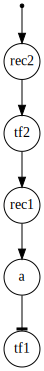

In [4]:
model.processed_graph.edge_subgraph(selected_idx).plot()


## Store the CORNETO result in AnnNet


In [5]:
G = an.AnnNet(directed=True)
edge_ids_by_pair = {}
for source, sign, target in pkn_tuples:
    effect = 'activates' if sign > 0 else 'inhibits'
    edge_id = f'{source}_{effect}_{target}'
    G.add_edges(
        source,
        target,
        edge_id=edge_id,
        weight=abs(sign),
        interaction=sign,
        effect=effect,
    )
    edge_ids_by_pair[(source, target)] = edge_id

selected_edges = []
for edge_obj, row in edge_values.iterrows():
    source, target = edge_obj
    activity = int(row['edge_activity'])
    if activity == 0 or len(source) != 1 or len(target) != 1:
        continue
    pair = (next(iter(source)), next(iter(target)))
    edge_id = edge_ids_by_pair.get(pair)
    if edge_id is None:
        continue
    selected_edges.append(edge_id)
    G.attrs.set_edge_attrs(edge_id, corneto_activity=activity)

for node, row in vertex_values.iterrows():
    if str(node) in G.vertices():
        G.attrs.set_vertex_attrs(str(node), corneto_activity=int(row['node_activity']))

G.slices.add('corneto_signal')
G.slices.add_edges('corneto_signal', selected_edges)

selected_labels = {
    row['edge_id']: f"{row['source']} -> {row['target']}"
    for row in G.views.edges().iter_rows(named=True)
}
print('AnnNet shape:', G.shape)
print('selected edges:', [selected_labels[eid] for eid in sorted(selected_edges)])
G.views.edges().select(
    ['edge_id', 'source', 'target', 'effect', 'corneto_activity']
)


AnnNet shape: (12, 24)
selected edges: ['a -> tf1', 'rec1 -> a', 'rec2 -> tf2', 'tf2 -> rec1']


edge_id,source,target,effect,corneto_activity
str,str,str,str,i64
"""rec1_activates_a""","""rec1""","""a""","""activates""",1
"""rec1_inhibits_b""","""rec1""","""b""",null,null
"""rec1_activates_f""","""rec1""","""f""",null,null
"""rec1_inhibits_c""","""rec1""","""c""",null,null
"""rec2_activates_b""","""rec2""","""b""",null,null
…,…,…,…,…
"""c_inhibits_tf2""","""c""","""tf2""",null,null
"""tf1_activates_tf2""","""tf1""","""tf2""",null,null
"""tf1_inhibits_rec2""","""tf1""","""rec2""",null,null


## AnnNet solution slice


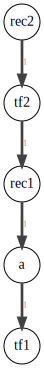

In [6]:
from annnet.utils import plotting

solution = G.subgraph_from_slice('corneto_signal')
plotting.plot(solution, backend='graphviz', show_edge_labels=True)


The CORNETO solve remains reproducible in the notebook, while
AnnNet keeps the result attached to a graph object that can be
sliced, annotated, exported, or combined with other analyses.
